### Clustering

<br>

<div class="exercise"><b>Questão:</b> Por quê o clustering é importante?</div>

O clustering é importante porque permite identificar padrões ocultos e segmentar dados em grupos semelhantes, facilitando a análise e melhorando a precisão de modelos, sem a necessidade de rótulos predefinidos.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing

%matplotlib inline 

In [9]:
# Carrega dados e apresenta algumas estatícticas
multishapes = pd.read_csv("multishapes.csv")
ms_df = multishapes[['x','y']]
ms_df.describe()

,x,y
count,1100.000000,1100.000000
mean,-0.081222,-0.625431
std,0.644967,1.176170
min,-1.489180,-3.353462
25%,-0.478839,-1.126752
50%,-0.132920,-0.297040
75%,0.366072,0.250817
max,1.492208,1.253874


In [10]:
# Normalizar os dados
scaled_df = pd.DataFrame(preprocessing.scale(ms_df), index=multishapes['shape'], columns = ms_df.columns)
scaled_df.describe()

,x,y
count,1.100000e+03,1100.000000
mean,4.521636e-17,0.000000
std,1.000455e+00,1.000455
min,-2.183985e+00,-2.320473
25%,-6.167723e-01,-0.426425
50%,-8.019252e-02,0.279331
75%,6.938298e-01,0.745340
max,2.440659e+00,1.598544


<b>Que tipo de normalização foi utilizada? </b>
<br>A normalização utilizada é a normalização Z-score, que transforma os dados para que tenham média 0 e desvio padrão 1.

<b>É necessário sempre normalizar os dados antes de agrupar?</b>
<br>A normalização é mais relevante quando as variáveis têm escalas diferentes e você deseja evitar que variáveis com maior amplitude dominem os resultados. No entanto, se todas as variáveis já estiverem na mesma escala ou se não houver um impacto significativo das escalas, a normalização pode não ser necessária antes do agrupamento.


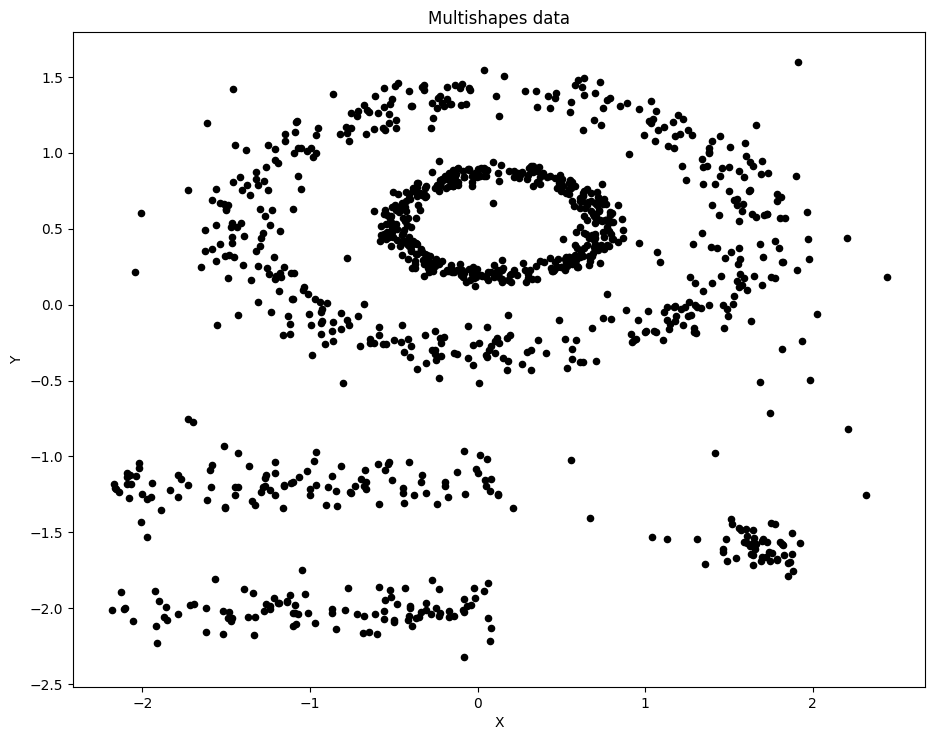

In [11]:
# Plotar os dados
msplot = scaled_df.plot.scatter(x='x',y='y',c='Black',title="Multishapes data",figsize=(11,8.5))
msplot.set_xlabel("X")
msplot.set_ylabel("Y")
plt.show()

## k-Means clustering:

<br>

<div class="exercise"  style="background-color:#b3e6ff"><b>Questão</b>: Como o k-Means funciona? </div>

In [19]:
from sklearn.cluster import KMeans
ms_kmeans = KMeans(n_clusters=5, init='random', n_init=3, random_state=109).fit(scaled_df)

### Plotting

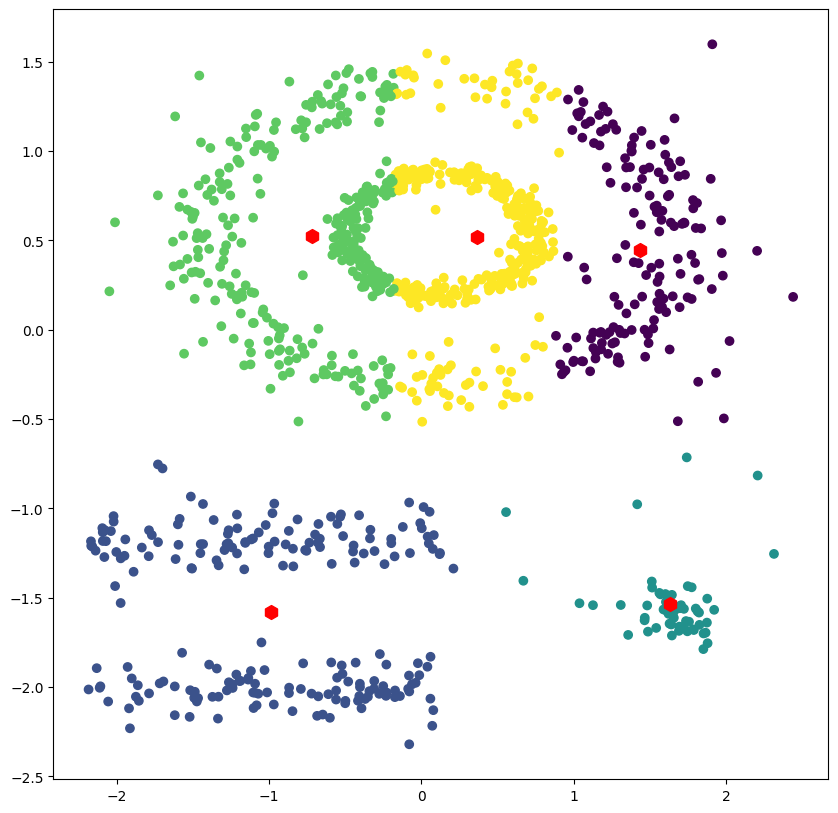

In [20]:
plt.figure(figsize=(10,10))
plt.scatter(scaled_df['x'],scaled_df['y'], c=ms_kmeans.labels_);
plt.scatter(ms_kmeans.cluster_centers_[:,0],ms_kmeans.cluster_centers_[:,1], c='r', marker='h', s=100);

<div class="exercise"><b>Questão</b>: Esse resultado era esperado ou alguma coisa deu errado? Nós devemos sempre normalizar os dados antes de agrupar?</div>

O algoritmo que os clusters são esféricos e têm variâncias semelhantes. Porém, o gráfico mostra clusters de formatos distintos.
O fato de alguns pontos estarem agrupados incorretamente sugere que K-Means não conseguiu lidar bem com essa estrutura, o que era esperado devido às limitações do algoritmo.


### Características:
 - Problema de inicialização; deve ser rodado várias vezes
 - A distância total ao quadrado nunca deve piorar durante uma atualização
 - k-Means pode lutar com clusters que estão próximos; eles podem ser agrupados em um
 - Não há noção de 'não faz parte de nenhum cluster' ou 'parte de dois clusters'
 - [Visualização aqui](http://web.stanford.edu/class/ee103/visualizations/kmeans/kmeans.html)

## Agglomerative Clustering

<br>

<div class="exercise"><b>Questão</b>: Como o algoritmo Hierarchical Agglomerative Clustering funciona? </div>

Funciona agrupando pontos de forma hierárquica, começando com cada ponto como um cluster individual e, em cada iteração, mesclando os dois clusters mais próximos até restar apenas um. O resultado é uma árvore que pode ser cortada em diferentes níveis para definir os clusters finais.

In [15]:
from sklearn.cluster import AgglomerativeClustering

clustering = AgglomerativeClustering(n_clusters=5, linkage='ward', metric='euclidean').fit(scaled_df)

## Plotting

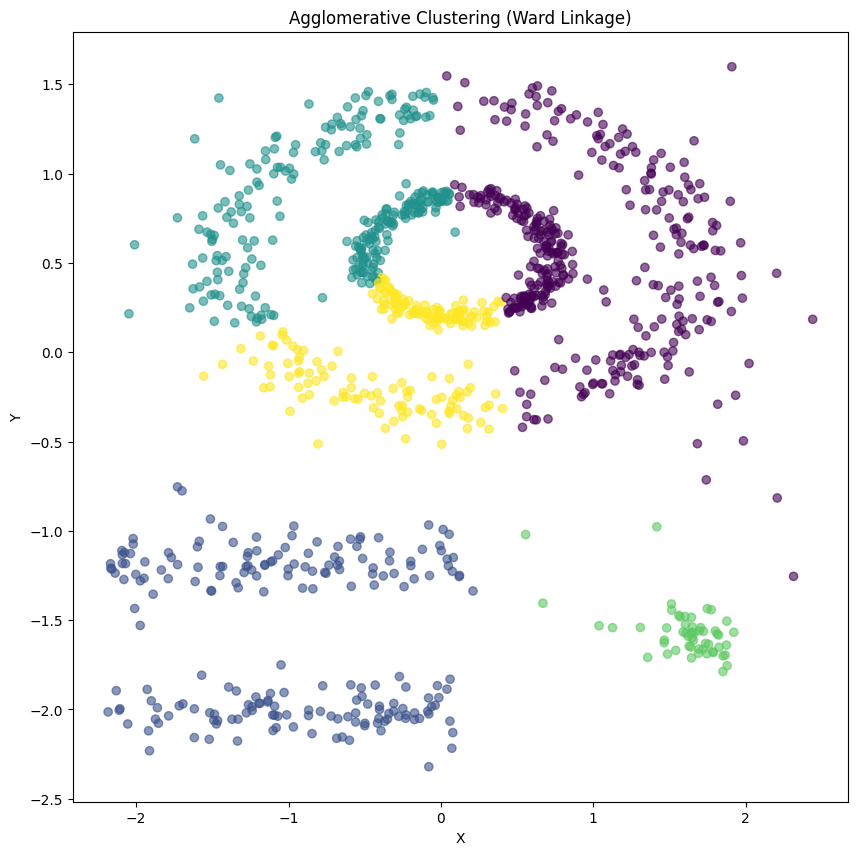

In [21]:
# Inserir o código para plotar os clusterings aqui
plt.figure(figsize=(10, 10))
plt.scatter(scaled_df['x'], scaled_df['y'], c=clustering.labels_, cmap='viridis', alpha=0.6)
plt.title("Agglomerative Clustering (Ward Linkage)")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

• O resultado era esperado ou alguma coisa deu errado? 

Não era o resultado esperado. Os clusters não ficaram muito bem separados.

### Características:
 - É custoso: complexidade de tempo O(n^3) e complexidade de espaço O(n^2).
 - Muitas opções de critérios de ligação (linkage)
 - Cada nó é agrupado (nenhum filho é deixado para trás)

## DBscan Clustering


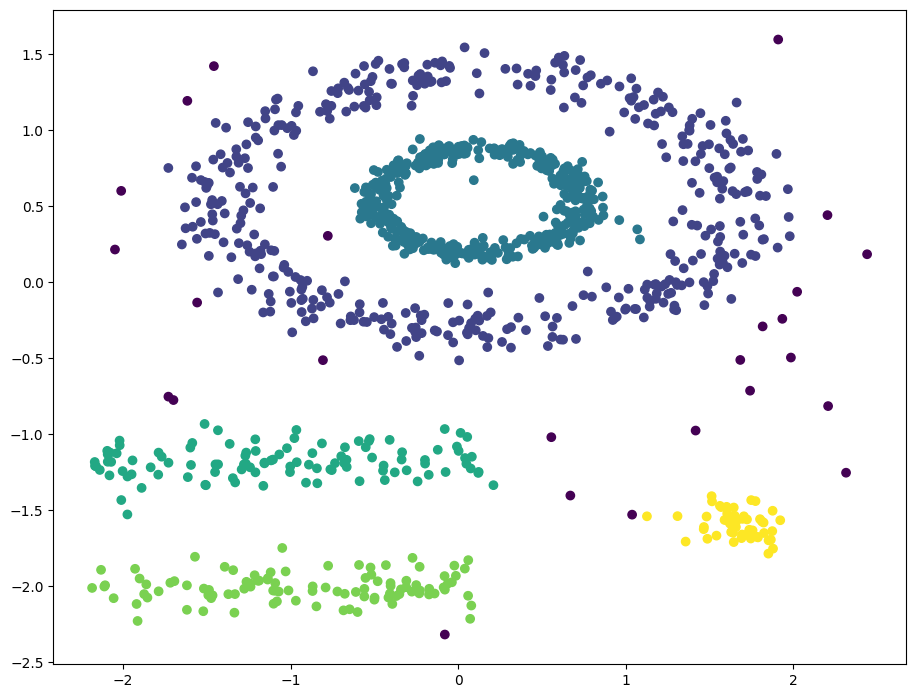

In [16]:
from sklearn.cluster import DBSCAN
plt.figure(figsize=(11,8.5))
fitted_dbscan = DBSCAN(eps=0.2).fit(scaled_df)
plt.scatter(scaled_df['x'],scaled_df['y'], c=fitted_dbscan.labels_);

<div class="exercise"><b>Exercício</b>: Altere os valores de epsilon e do min_samples e plote os resutados.</div>

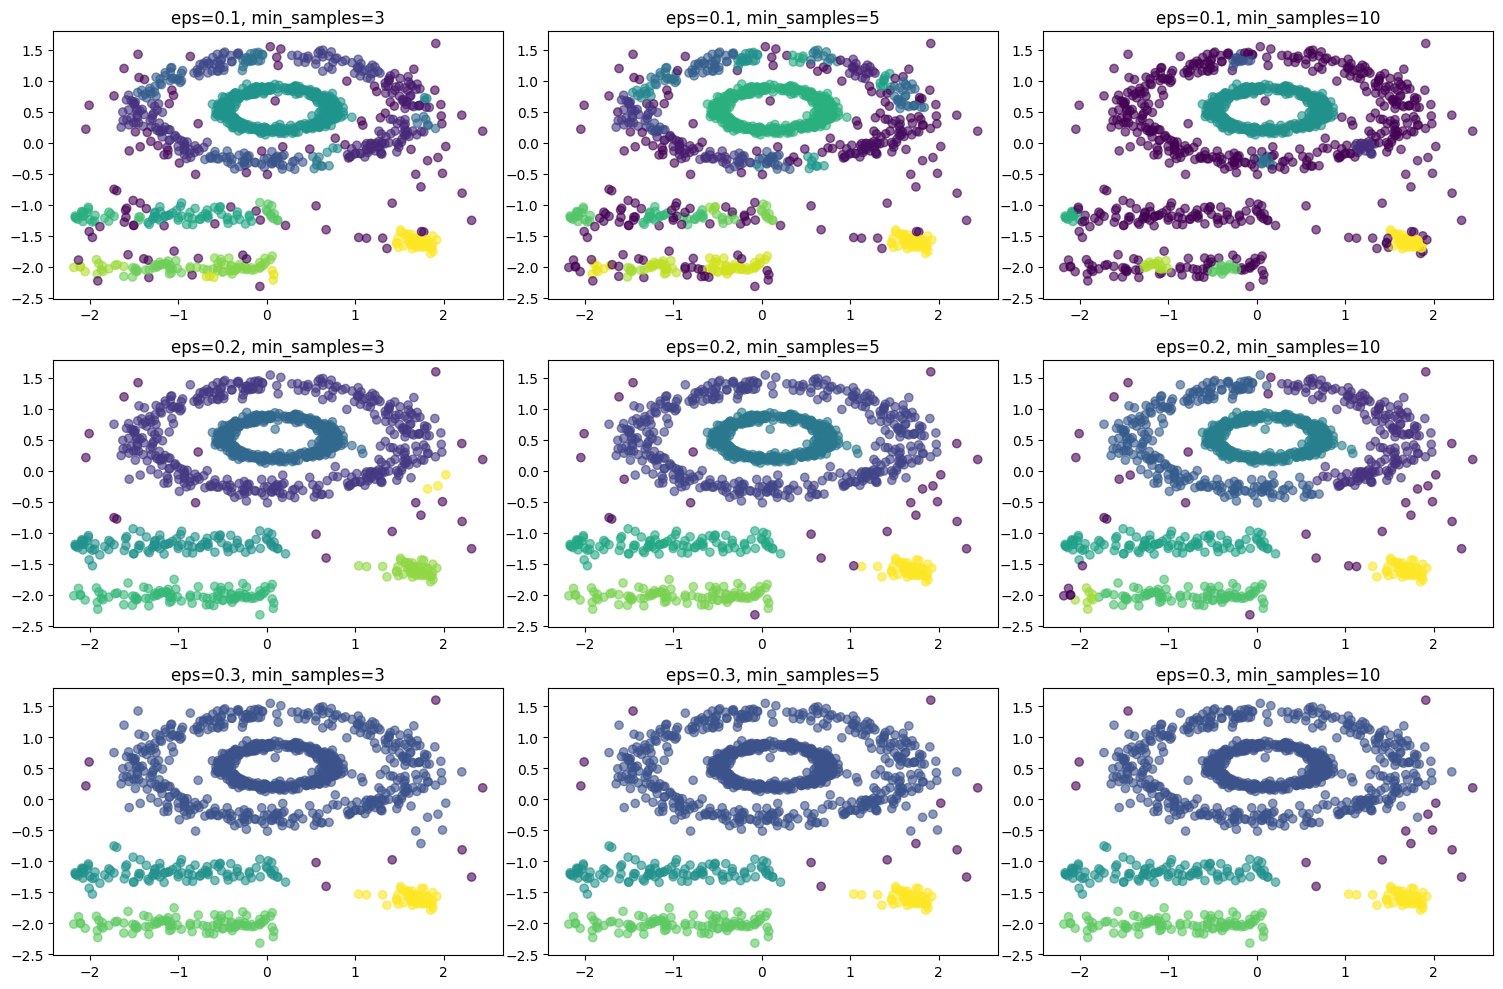

In [22]:
# Insira o codigo aqui (com a variação do epsilon e do min_samples)
# Testando diferentes valores de eps e min_samples
eps_values = [0.1, 0.2, 0.3]
min_samples_values = [3, 5, 10]

plt.figure(figsize=(15, 10))

for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples).fit(scaled_df)
        
        plt.subplot(len(eps_values), len(min_samples_values), i * len(min_samples_values) + j + 1)
        plt.scatter(scaled_df['x'], scaled_df['y'], c=dbscan.labels_, cmap='viridis', alpha=0.6)
        plt.title(f"eps={eps}, min_samples={min_samples}")

plt.tight_layout()
plt.show()

### Características:
 - Pode agrupar relacionamentos não lineares muito bem; potencial para agrupamentos mais naturais e de formato arbitrário
 - Não requer a especificação do número de clusters (ou seja, ** k **); o algoritmo determina tal
 - Robusto para outliers
 - Muito sensível aos parâmetros (requer forte conhecimento dos dados)
 - Não garante que todos (ou QUALQUER) item será agrupado
 
<br>

<div class="discussion"><b>Discussão</b>: </div>Quando devemos preferir um tipo de cluster a outro? Devemos sempre tentar todos eles? Imagine que você trabalha no Spotify e deseja criar playlists personalizadas para cada pessoa. Pode-se imaginar que existe um conjunto de dados em que cada linha é uma música específica e as colunas são características (por exemplo, tempo (BPM), frequência vocal média, quantidade de baixo, sentimento das letras, duração em segundos, etc). Vamos usar o agrupamento para agrupar o catálogo de músicas favoritas de alguém, que servirá como pontos de partida separados para sugerir músicas futuras. Especificamente, imagine que você 'gostou' de 500 músicas no Spotify até agora, e seu algoritmo de recomendação precisa agrupar essas 500 músicas. Você primeiro experimentaria com k-Means, aglomerativo ou DBScan? Por quê?


Eu começaria testando DBSCAN, porque ele pode identificar clusters de diferentes formatos e lidar com outliers, o que faz sentido para músicas, já que os gostos podem variar bastante. K-Means assume clusters esféricos, então pode não ser ideal se as músicas tiverem padrões complexos. Aglomerativo pode ser interessante se quisermos entender relações hierárquicas entre gêneros, mas pode ser mais pesado computacionalmente. No fim, testar mais de um método pode ser útil, mas DBSCAN parece a melhor escolha inicial.